In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import re
from wordcloud import WordCloud
from collections import Counter
import emoji
import string

In [4]:
!pip install wordcloud emoji

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 590.6/590.6 kB 13.4 MB/s eta 0:00:00


In [8]:
df = pd.read_csv("../datasets/train.csv")  #load dataset
df.head()

#print data
print(f"Total samples: {len(df)}") 
print(df.columns)
print(df['target'].value_counts())  # 1 = disaster, 0 = not

Total samples: 7613
Index(['id', 'keyword', 'location', 'text', 'target'], dtype='object')
target
0    4342
1    3271
Name: count, dtype: int64


In [7]:
import os
print(os.getcwd())

/Volumes/T7/dev/nlp-comp-env/notebooks


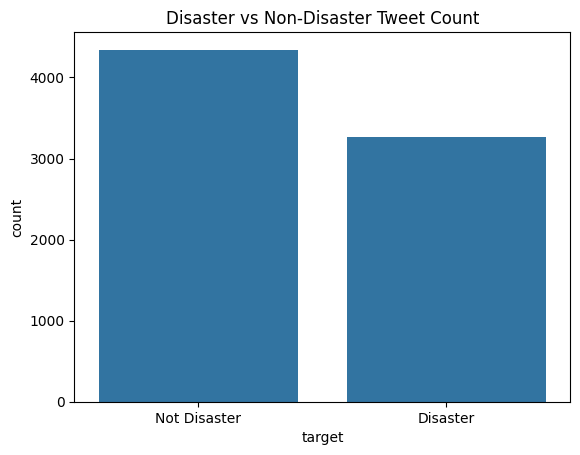

In [9]:
sns.countplot(x="target", data=df)
plt.title("Disaster vs Non-Disaster Tweet Count")
plt.xticks([0, 1], ["Not Disaster", "Disaster"])
plt.show()

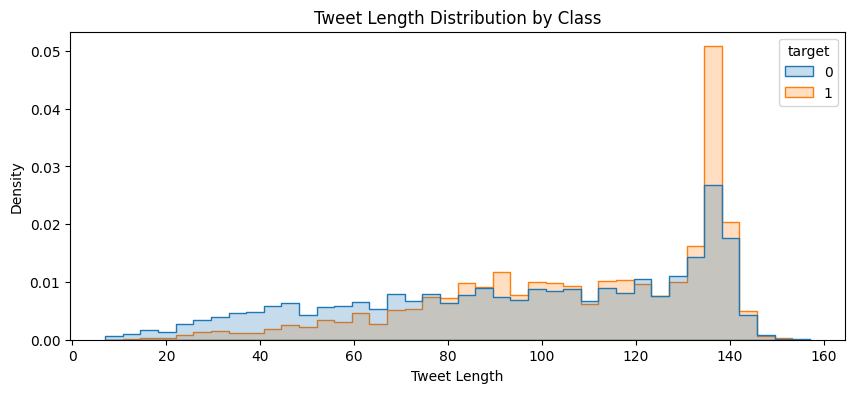

In [12]:
df["text_len"] = df["text"].apply(len)

plt.figure(figsize=(10, 4))
sns.histplot(data=df, x="text_len", hue="target", bins=40, element="step", stat="density", common_norm=False)
plt.title("Tweet Length Distribution by Class")
plt.xlabel("Tweet Length")
plt.show()

In [14]:
print("Non-Disaster Example:\n", df[df["target"] == 0]["text"].sample(1).values[0])
print("Disaster Example:\n", df[df["target"] == 1]["text"].sample(1).values[0])

Non-Disaster Example:
 candylit: Imagine sarumi in a zombie apocalypse Fighting back to back Heart to heart conversations over the... http://t.co/xIZkjffF29
Disaster Example:
 Fukushima 'mutant vegetable' images sweep across the region two years after nuclear disaster http://t.co/psi35AU3pc via @MailOnline


In [18]:
print("Non-Disaster Example:\n", df[df["target"] == 0]["text"].sample(1).values[0])
print("Disaster Example:\n", df[df["target"] == 1]["text"].sample(1).values[0])

Non-Disaster Example:
 @D33munni @JeanNamibian noooooooo ... *proceeds to fall off a cliff*
Disaster Example:
 HereÛªs how media in Pakistan covered the capture of terrorist Mohammed Naved http://t.co/3MtWh0jJns


In [19]:
print("Non-Disaster Example:\n", df[df["target"] == 0]["text"].sample(1).values[0])
print("Disaster Example:\n", df[df["target"] == 1]["text"].sample(1).values[0])

Non-Disaster Example:
 @Robot_Rainstorm I'm.sort of interested in what fonts they're using.
Disaster Example:
 Though serious #natural #disaster increased in #Japanjapan #Nuclear safety standard is far inferior to #US standard.#anonymous #Nytimes


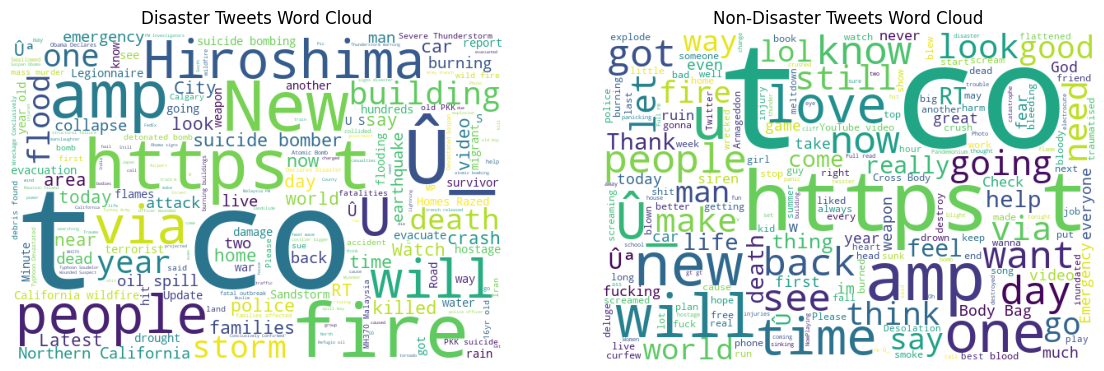

In [15]:
disaster_text = " ".join(df[df["target"] == 1]["text"])
nondisaster_text = " ".join(df[df["target"] == 0]["text"])

plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
plt.imshow(WordCloud(width=600, height=400, background_color="white").generate(disaster_text))
plt.title("Disaster Tweets Word Cloud")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(WordCloud(width=600, height=400, background_color="white").generate(nondisaster_text))
plt.title("Non-Disaster Tweets Word Cloud")
plt.axis("off")
plt.show()

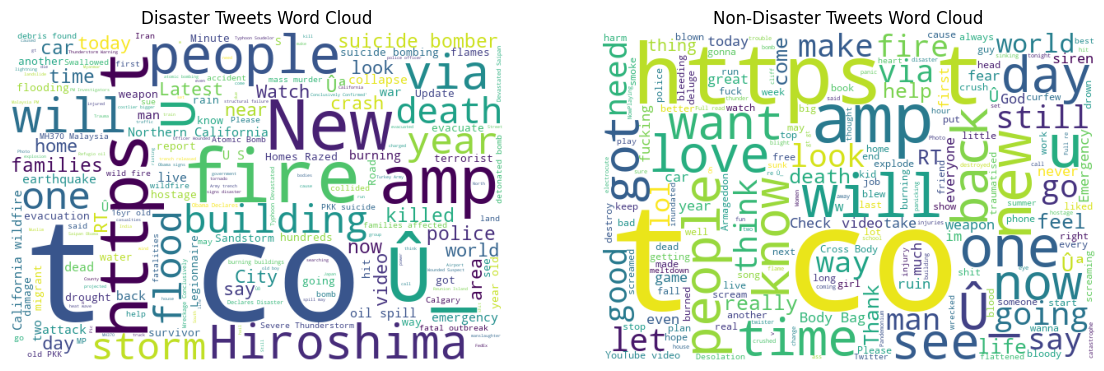

In [16]:
disaster_text = " ".join(df[df["target"] == 1]["text"])
nondisaster_text = " ".join(df[df["target"] == 0]["text"])

plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
plt.imshow(WordCloud(width=600, height=400, background_color="white").generate(disaster_text))
plt.title("Disaster Tweets Word Cloud")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(WordCloud(width=600, height=400, background_color="white").generate(nondisaster_text))
plt.title("Non-Disaster Tweets Word Cloud")
plt.axis("off")
plt.show()

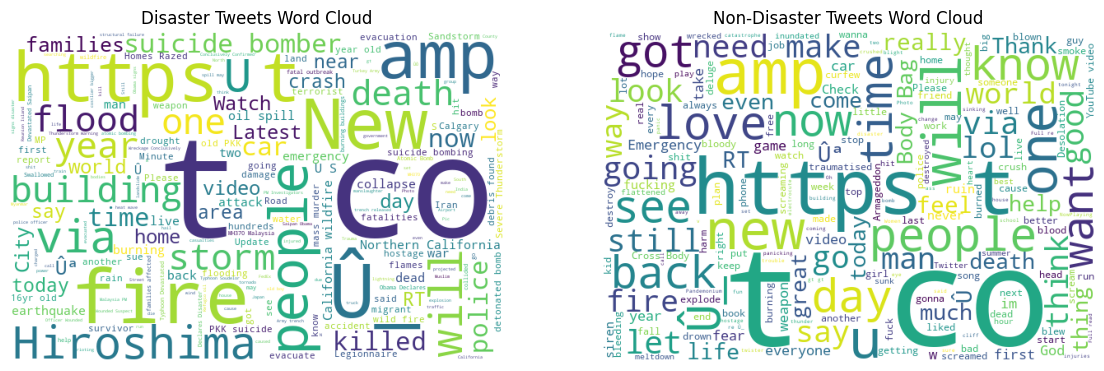

In [17]:
disaster_text = " ".join(df[df["target"] == 1]["text"])
nondisaster_text = " ".join(df[df["target"] == 0]["text"])

plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
plt.imshow(WordCloud(width=600, height=400, background_color="white").generate(disaster_text))
plt.title("Disaster Tweets Word Cloud")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(WordCloud(width=600, height=400, background_color="white").generate(nondisaster_text))
plt.title("Non-Disaster Tweets Word Cloud")
plt.axis("off")
plt.show()

In [20]:
def extract_emojis(text):
    return [c for c in text if c in emoji.EMOJI_DATA]

all_emojis = df["text"].apply(extract_emojis)
flat_emojis = [e for sub in all_emojis for e in sub]
emoji_counts = Counter(flat_emojis)

print("Top Emojis:", emoji_counts.most_common(10))

Top Emojis: [('©', 10)]


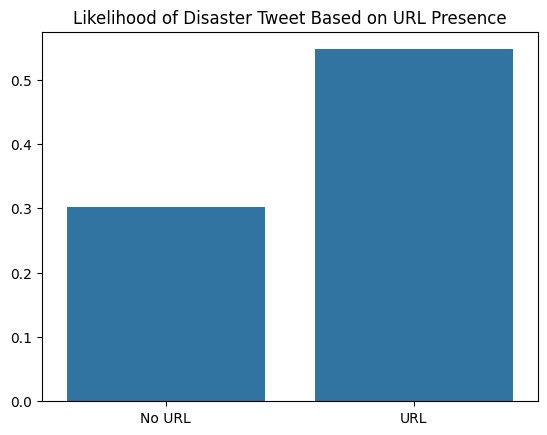

In [22]:
df["has_url"] = df["text"].str.contains("http")
df["has_mention"] = df["text"].str.contains("@")

sns.barplot(x=["No URL", "URL"], y=df.groupby("has_url")["target"].mean().values)
plt.title("Likelihood of Disaster Tweet Based on URL Presence")
plt.show()